# 고객 행동 데이터 분석 통한 개인 맞춤형 식료품 당일 배송 서비스 개선
### 팀 데2터 | 이성준 · 진보원 · 최민범 · 최민영

> **실제 데이터 기반 분석 프로젝트**  
> D사 친환경 식료품 당일배송 서비스의 고객 행동 데이터를 분석하여 구독 전환·리텐션 전략을 도출합니다.

---

### 데이터 구성
| 파일 | 내용 |
|------|------|
| Member_Data.csv | 회원 정보 (12,540명 – 회원상태·성별·나이·구독여부·주소지 등) |
| Product_Data.csv | 상품 정보 (2,549개 – 물품명·대분류·중분류·중량) |
| Sales_Data05_part1~3.csv | 주문 데이터 (668,111건, 2021.01~10 – 구매금액·배송일·적립금 등) |

### 분석 목표
1. **구독 전환 요인 분석** – 구독 vs 비구독 소비 패턴 비교, t-test 유의성 검증  
2. **시기별 구매 트렌드** – 월별/계절별 인기 상품 도출, FP-Growth 연관 분석  
3. **휴면 고객 분석** – RFM 기반 휴면 정의, 위험군 세분화, 리텐션 전략 수립


## 0. 라이브러리 및 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
from scipy.stats import ttest_ind, mannwhitneyu
from mlxtend.frequent_patterns import fpgrowth, association_rules
import warnings
warnings.filterwarnings("ignore")

# ── 한글 폰트 설정 (sns.set_style 이후에도 유지) ──────────────
_preferred = ["NanumGothic","NanumBarunGothic","Malgun Gothic","AppleGothic"]
_available = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _preferred if f in _available), None)

sns.set_style("whitegrid")
if _font:
    plt.rcParams["font.family"] = _font
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = Path("/mnt/user-data/outputs/data2")   # 실행 환경에 맞게 수정
print("환경 설정 완료  |  폰트:", _font or "기본폰트")


환경 설정 완료  |  폰트: 기본폰트


## 1. 데이터 로드 및 기본 탐색

Sales_Data05는 3개 파일로 분할되어 있어 합친 후 사용합니다.


In [2]:
# ── 회원 / 상품 데이터 ────────────────────────────────────────
mem  = pd.read_csv(DATA_DIR / "Member_Data.csv",  encoding="euc-kr")
prod = pd.read_csv(DATA_DIR / "Product_Data.csv", encoding="utf-8-sig")

# ── 판매 데이터 (3-part 합치기) ───────────────────────────────
parts = [
    pd.read_csv(DATA_DIR / f"Sales_Data05_part{i}_balanced.csv", encoding="utf-8-sig")
    for i in [1, 2, 3]
]
sales = pd.concat(parts, ignore_index=True)

# 날짜 변환
for col in ["주문일시","배송시작일","배송완료일"]:
    sales[col] = pd.to_datetime(sales[col], errors="coerce")

print(f"Member_Data  : {mem.shape[0]:,}행 × {mem.shape[1]}열")
print(f"Product_Data : {prod.shape[0]:,}행 × {prod.shape[1]}열")
print(f"Sales_Data05 : {sales.shape[0]:,}행 × {sales.shape[1]}열")
print(f"분석 기간     : {sales['주문일시'].min().date()} ~ {sales['주문일시'].max().date()}")
display(sales.head(3))


Member_Data  : 12,540행 × 10열
Product_Data : 2,549행 × 5열
Sales_Data05 : 668,111행 × 12열
분석 기간     : 2021-01-02 ~ 2021-10-31


,회원번호,회원상태,구매수량,구매금액,주문일시,배송시작일,배송완료일,사용 적립금,사용 포인트 네이버,주문취소여부,주문시간,제품번호
0,1032097472,정상회원,1.0,7083,2021-01-02,NaT,NaT,0,0,주문취소,오후 12:60,100021783V2_1337
1,1032097472,정상회원,1.0,29865,2021-01-02,2021-01-02,2021-01-02,0,0,NaN,오후 12:60,100022137V2_1606
2,1032097472,정상회원,1.0,23164,2021-01-02,2021-01-02,2021-01-03,0,0,NaN,오후 12:60,100021452V2_1113


## 2. 데이터 전처리

- 주문취소 제외 → 유효 주문만 사용
- 제품번호 기준으로 Product_Data 병합
- 회원번호 기준으로 Member_Data 병합


In [3]:
# ── 유효 주문 필터링 ──────────────────────────────────────────
valid = sales[sales["주문취소여부"].isna()].copy()
print(f"전체 주문: {len(sales):,}건  |  주문취소: {sales['주문취소여부'].notna().sum():,}건  |  유효 주문: {len(valid):,}건")

# ── 결측치 확인 ───────────────────────────────────────────────
print("\n[결측치 현황]")
display(pd.DataFrame({
    "결측치 수": mem.isna().sum(),
    "결측률(%)": (mem.isna().sum()/len(mem)*100).round(1)
})[lambda df: df["결측치 수"]>0])

# ── 배송일수 파생 변수 ────────────────────────────────────────
valid["배송일수"] = (valid["배송완료일"] - valid["배송시작일"]).dt.days
print(f"\n평균 배송일수: {valid['배송일수'].mean():.2f}일")
print(f"당일 배송 비율: {(valid['배송일수']==0).mean():.1%}")

# ── Product 병합 ──────────────────────────────────────────────
valid_p = valid.merge(prod[["제품번호","물품명","물품대분류","물품중분류"]], on="제품번호", how="left")
print(f"\n상품 매핑률: {valid_p['물품명'].notna().mean():.1%}")


전체 주문: 668,111건  |  주문취소: 30,635건  |  유효 주문: 637,476건

[결측치 현황]


,결측치 수,결측률(%)
회원상태,1,0.0
성별,1,0.0
등록카드,15,0.1
결혼,2717,21.7
구독여부,2346,18.7
주소지,3,0.0
세부주소지,9,0.1



평균 배송일수: 0.69일
당일 배송 비율: 46.5%

상품 매핑률: 100.0%


## 3. 회원 현황 탐색 (EDA)


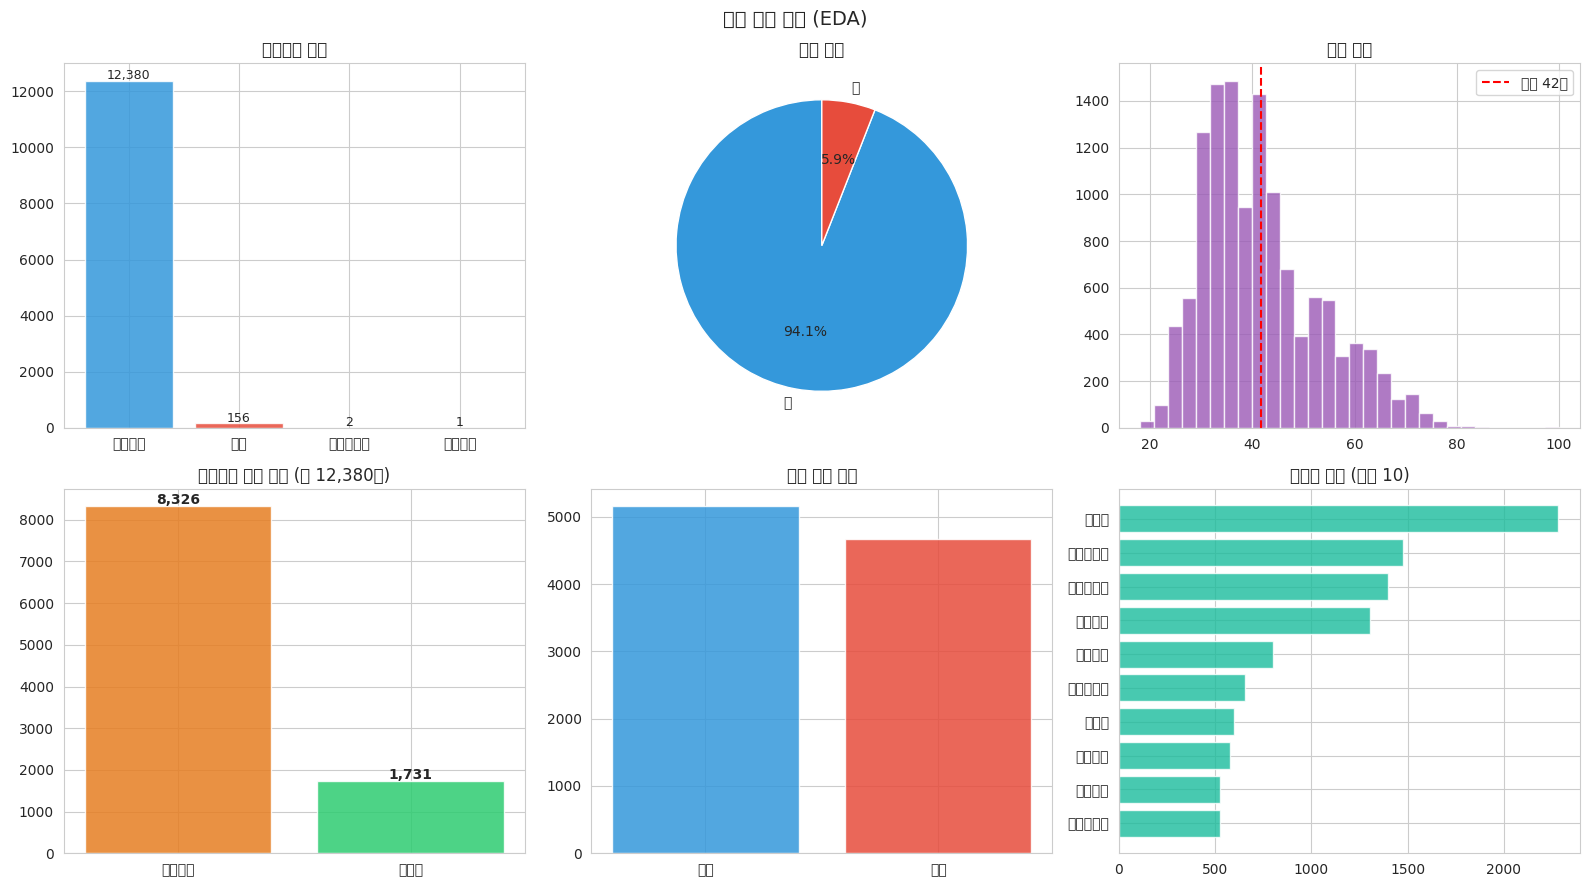

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 회원상태
wn = mem["회원상태"].value_counts()
axes[0,0].bar(wn.index, wn.values, color=["#3498db","#e74c3c","#e67e22","#95a5a6"], alpha=0.85)
axes[0,0].set_title("회원상태 분포")
for i,v in enumerate(wn.values):
    axes[0,0].text(i, v+50, f"{v:,}", ha="center", fontsize=9)

# 성별
gn = mem["성별"].value_counts()
axes[0,1].pie(gn.values, labels=gn.index, autopct="%1.1f%%",
              colors=["#3498db","#e74c3c"], startangle=90)
axes[0,1].set_title("성별 분포")

# 나이 히스토그램
axes[0,2].hist(mem["나이"].dropna(), bins=30, color="#9b59b6", alpha=0.8, edgecolor="white")
axes[0,2].axvline(mem["나이"].mean(), color="red", linestyle="--", label=f"평균 {mem['나이'].mean():.0f}세")
axes[0,2].set_title("나이 분포")
axes[0,2].legend()

# 구독여부 (정상회원 기준)
normal = mem[mem["회원상태"]=="정상회원"]
sub_cnt = normal["구독여부"].value_counts()
axes[1,0].bar(["비구독자","구독자"], [sub_cnt.get(False,0), sub_cnt.get(True,0)],
              color=["#e67e22","#2ecc71"], alpha=0.85)
axes[1,0].set_title(f"정상회원 구독 현황 (총 {len(normal):,}명)")
for i,v in enumerate([sub_cnt.get(False,0), sub_cnt.get(True,0)]):
    axes[1,0].text(i, v+50, f"{v:,}", ha="center", fontsize=10, fontweight="bold")

# 결혼 여부
mr = mem["결혼"].value_counts()
axes[1,1].bar(mr.index, mr.values, color=["#3498db","#e74c3c"], alpha=0.85)
axes[1,1].set_title("결혼 여부 분포")

# 주소지 상위10
region = mem["주소지"].value_counts().head(10)
axes[1,2].barh(region.index[::-1], region.values[::-1], color="#1abc9c", alpha=0.8)
axes[1,2].set_title("주소지 분포 (상위 10)")

plt.suptitle("회원 현황 탐색 (EDA)", fontsize=14)
plt.tight_layout()
plt.show()


## 4. 구독 전환에 영향 미치는 요소 확인
### (발표자료 데이터 분석 1 – 슬라이드 14)

정상회원 기준 구독자 vs 비구독자의 소비 지표를 비교합니다.


In [5]:
# ── 회원별 구매 요약 ──────────────────────────────────────────
snapshot = pd.Timestamp("2021-10-31")

member_stats = valid.groupby("회원번호").agg(
    구매횟수   =("구매금액", "count"),
    총구매금액  =("구매금액", "sum"),
    평균구매금액 =("구매금액", "mean"),
    적립금사용  =("사용 적립금",         lambda x: (x>0).any()),
    포인트사용  =("사용 포인트 네이버",   lambda x: (x>0).any()),
).reset_index()

# 월평균 구매횟수 계산
valid["월"] = valid["주문일시"].dt.to_period("M")
monthly_cnt = valid.groupby(["회원번호","월"]).size().reset_index(name="월구매횟수")
monthly_avg = monthly_cnt.groupby("회원번호")["월구매횟수"].mean().reset_index()
monthly_avg.columns = ["회원번호","월평균구매횟수"]

# 구매 대분류 수
prod_div = valid_p.groupby("회원번호")["물품대분류"].nunique().reset_index()
prod_div.columns = ["회원번호","구매대분류수"]

member_full = (member_stats
               .merge(monthly_avg, on="회원번호")
               .merge(prod_div, on="회원번호")
               .merge(mem[["회원번호","구독여부","나이","성별","결혼","주소지","회원상태"]], on="회원번호", how="left"))

normal_m = member_full[member_full["회원상태"]=="정상회원"].copy()
sub_m    = normal_m[normal_m["구독여부"]==True]
nonsub_m = normal_m[normal_m["구독여부"]==False]

print(f"분석 대상: 구독자 {len(sub_m):,}명 / 비구독자 {len(nonsub_m):,}명")
print()

# 비교 표 (슬라이드 14 수치)
compare = pd.DataFrame({
    "구분":       ["비구독자","구독자"],
    "총구매금액(원)":    [nonsub_m["총구매금액"].mean(), sub_m["총구매금액"].mean()],
    "구매횟수(회)":      [nonsub_m["구매횟수"].mean(),   sub_m["구매횟수"].mean()],
    "평균구매금액(원)":  [nonsub_m["평균구매금액"].mean(), sub_m["평균구매금액"].mean()],
    "구매대분류수(종)":  [nonsub_m["구매대분류수"].mean(), sub_m["구매대분류수"].mean()],
    "적립금사용율":      [(nonsub_m["적립금사용"]==True).mean(), (sub_m["적립금사용"]==True).mean()],
    "포인트사용율":      [(nonsub_m["포인트사용"]==True).mean(), (sub_m["포인트사용"]==True).mean()],
}).set_index("구분")

display(compare.round(3))


분석 대상: 구독자 1,725명 / 비구독자 8,302명



,총구매금액(원),구매횟수(회),평균구매금액(원),구매대분류수(종),적립금사용율,포인트사용율
구분,,,,,,
비구독자,611181.767,51.428,13864.579,13.405,0.521,0.276
구독자,600174.201,51.811,12847.966,13.772,0.517,0.288


=== 통계 검정 결과 ===

[월평균 구매횟수에 따른 구독 전환 여부 검정]
  귀무가설: 월평균 구매횟수에 따른 구독 전환 여부 차이가 없다
  대립가설: 월평균 구매횟수에 따른 구독 전환 여부 차이가 있다
  P-value = 0.5613  (>= 0.05 → 채택)
  결론: 소비 패턴에 따른 구독 전환 여부 차이가 없다

[적립금 및 네이버포인트 사용여부에 따른 구독 전환 여부 검정]
  적립금   P-value = 0.7373  (비유의)
  네이버포인트 P-value = 0.3047  (비유의)
  결론: 적립금 및 네이버포인트에 따른 구독 전환 여부 차이가 없다

→ 두 집단의 소비 지표는 전반적으로 유사
→ 구독 전환은 '소비 규모'가 아닌 '소비 패턴 및 이용 방식'에서 발생할 것으로 예측


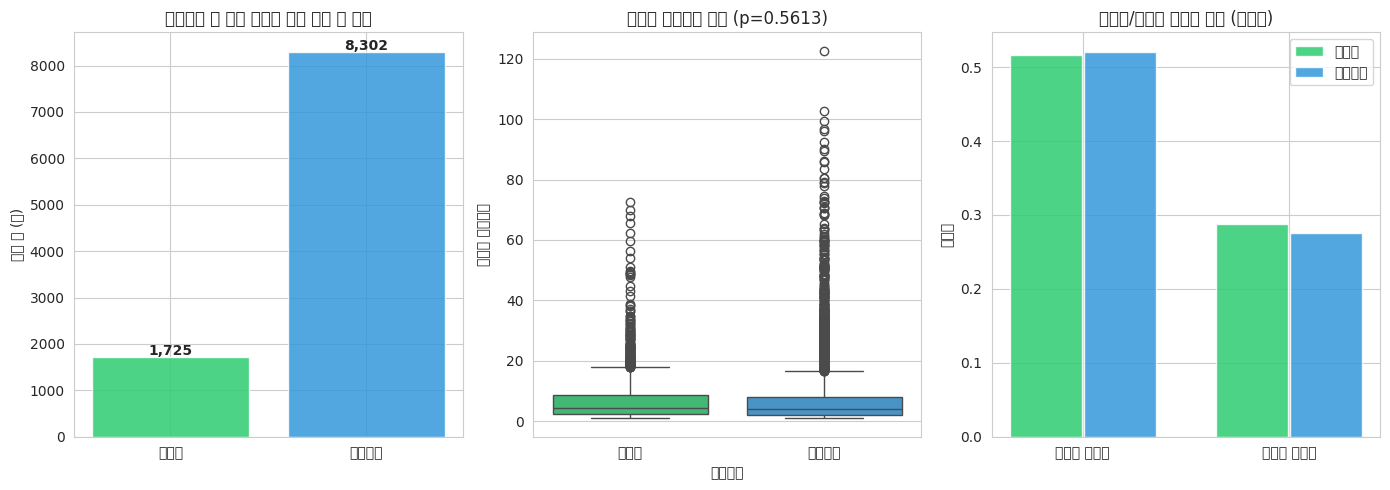

In [6]:
# ── t-test 검정 ───────────────────────────────────────────────
print("=== 통계 검정 결과 ===\n")

# 1. 월평균 구매횟수
t1, p1 = ttest_ind(sub_m["월평균구매횟수"].dropna(),
                    nonsub_m["월평균구매횟수"].dropna(), equal_var=False)
print("[월평균 구매횟수에 따른 구독 전환 여부 검정]")
print(f"  귀무가설: 월평균 구매횟수에 따른 구독 전환 여부 차이가 없다")
print(f"  대립가설: 월평균 구매횟수에 따른 구독 전환 여부 차이가 있다")
print(f"  P-value = {p1:.4f}  ({'< 0.05 → 기각' if p1<0.05 else '>= 0.05 → 채택'})")
print(f"  결론: 소비 패턴에 따른 구독 전환 여부 {'차이가 있다' if p1<0.05 else '차이가 없다'}\n")

# 2. 적립금 사용 여부
t2, p2 = ttest_ind(
    (sub_m["적립금사용"]==True).astype(int),
    (nonsub_m["적립금사용"]==True).astype(int), equal_var=False)
t3, p3 = ttest_ind(
    (sub_m["포인트사용"]==True).astype(int),
    (nonsub_m["포인트사용"]==True).astype(int), equal_var=False)

print("[적립금 및 네이버포인트 사용여부에 따른 구독 전환 여부 검정]")
print(f"  적립금   P-value = {p2:.4f}  ({'유의' if p2<0.05 else '비유의'})")
print(f"  네이버포인트 P-value = {p3:.4f}  ({'유의' if p3<0.05 else '비유의'})")
print(f"  결론: 적립금 및 네이버포인트에 따른 구독 전환 여부 차이가 없다")
print()
print("→ 두 집단의 소비 지표는 전반적으로 유사")
print("→ 구독 전환은 '소비 규모'가 아닌 '소비 패턴 및 이용 방식'에서 발생할 것으로 예측")

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 구독자 수 비교
axes[0].bar(["구독자","비구독자"], [len(sub_m), len(nonsub_m)],
            color=["#2ecc71","#3498db"], alpha=0.85)
axes[0].set_title("정상회원 중 구독 여부에 따른 회원 수 비교")
axes[0].set_ylabel("회원 수 (명)")
for i,v in enumerate([len(sub_m), len(nonsub_m)]):
    axes[0].text(i, v+30, f"{v:,}", ha="center", fontweight="bold")

# 월평균 구매횟수 BoxPlot
plot_df = pd.concat([
    sub_m[["월평균구매횟수"]].assign(구독여부="구독자"),
    nonsub_m[["월평균구매횟수"]].assign(구독여부="비구독자")
])
sns.boxplot(data=plot_df, x="구독여부", y="월평균구매횟수",
            palette={"구독자":"#2ecc71","비구독자":"#3498db"},
            hue="구독여부", legend=False, ax=axes[1])
if _font: plt.rcParams["font.family"] = _font
axes[1].set_title(f"월평균 구매횟수 비교 (p={p1:.4f})")
axes[1].set_ylabel("월평균 구매횟수")

# 적립금/포인트 사용율
cats = ["적립금 사용율","포인트 사용율"]
sub_vals    = [(sub_m["적립금사용"]==True).mean(), (sub_m["포인트사용"]==True).mean()]
nonsub_vals = [(nonsub_m["적립금사용"]==True).mean(), (nonsub_m["포인트사용"]==True).mean()]
x = np.arange(2)
axes[2].bar(x-0.18, sub_vals,    0.35, label="구독자",   color="#2ecc71", alpha=0.85)
axes[2].bar(x+0.18, nonsub_vals, 0.35, label="비구독자", color="#3498db", alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(cats)
axes[2].set_title("적립금/포인트 사용율 비교 (비유의)")
axes[2].set_ylabel("사용율")
axes[2].legend()

plt.tight_layout()
plt.show()


## 5. 시기에 따른 상품 주문 빈도 확인
### (발표자료 데이터 분석 2 – 슬라이드 15)

월별/계절별 인기 상품 Top3 및 FP-Growth 연관 분석을 수행합니다.


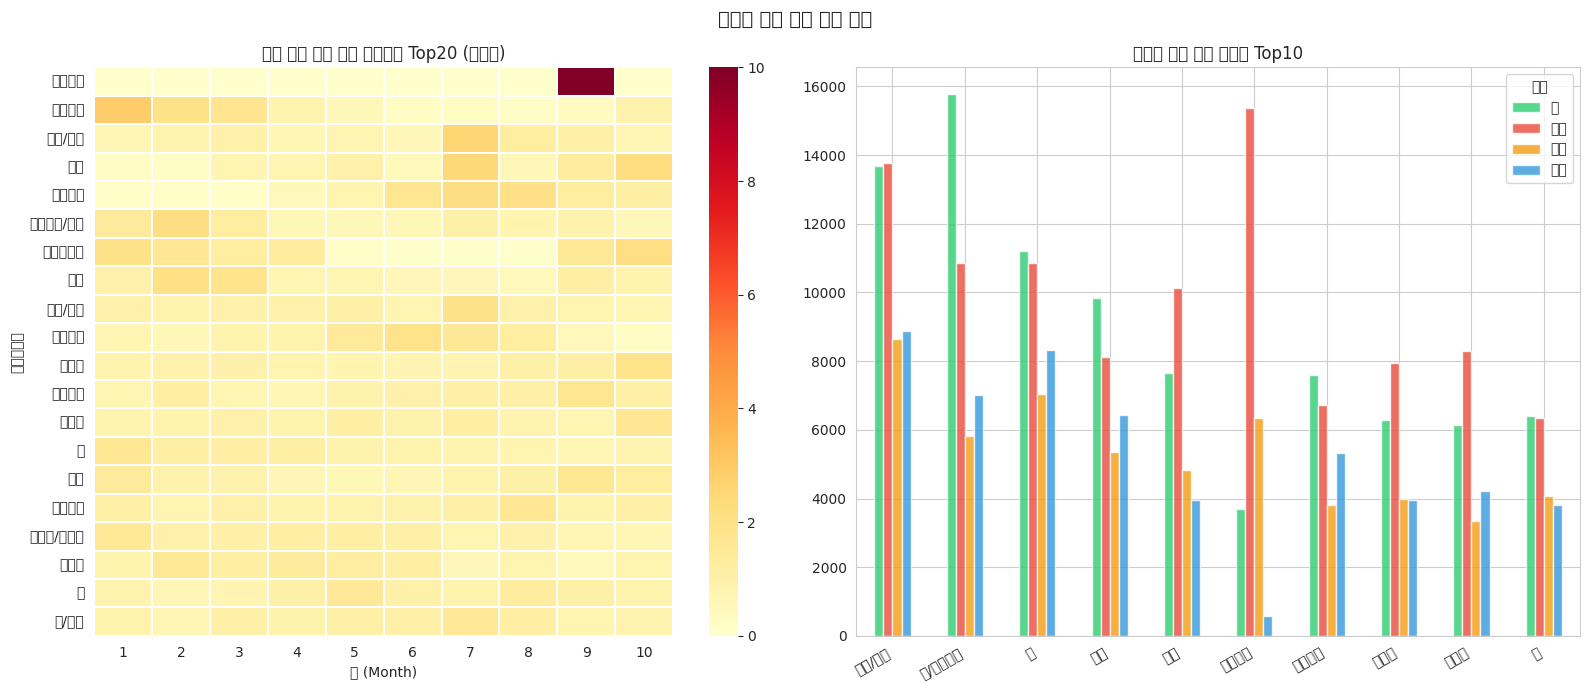


[계절별 인기 대분류 Top3]
  봄: ['잎/줄기채소', '두부/유부', '알']
  여름: ['열매채소', '두부/유부', '잎/줄기채소']
  가을: ['두부/유부', '알', '열매채소']
  겨울: ['두부/유부', '알', '잎/줄기채소']


In [7]:
valid_p["월"] = valid_p["주문일시"].dt.month
valid_p["계절"] = valid_p["월"].map({
    12:"겨울",1:"겨울",2:"겨울",
    3:"봄",  4:"봄",  5:"봄",
    6:"여름",7:"여름",8:"여름",
    9:"가을",10:"가을",11:"가을"
})

# ── 월별 주문 빈도 지수 ────────────────────────────────────────
prod_monthly = valid_p.groupby(["월","물품대분류"]).size().reset_index(name="주문건수")
prod_avg     = valid_p.groupby("물품대분류").size() / valid_p["월"].nunique()
prod_avg.name = "월평균"

prod_monthly = prod_monthly.merge(prod_avg.reset_index(), on="물품대분류")
prod_monthly["빈도지수"] = prod_monthly["주문건수"] / prod_monthly["월평균"]

# 월별 Top3 피벗
monthly_top = (prod_monthly.sort_values(["월","빈도지수"], ascending=[True,False])
               .groupby("월").head(3))

# 계절별 인기 대분류 Top3
seasonal_top = (valid_p.groupby(["계절","물품대분류"]).size()
                .reset_index(name="건수")
                .sort_values(["계절","건수"], ascending=[True,False])
                .groupby("계절").head(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 월별 히트맵
pivot = prod_monthly.pivot(index="물품대분류", columns="월", values="빈도지수").fillna(0)
top_items = (prod_monthly.groupby("물품대분류")["빈도지수"].max()
             .sort_values(ascending=False).head(20).index)
pivot_top = pivot.loc[top_items]

sns.heatmap(pivot_top, cmap="YlOrRd", ax=axes[0], annot=False, linewidths=0.3)
if _font: plt.rcParams["font.family"] = _font
axes[0].set_title("주문 빈도 기반 월별 인기상품 Top20 (대분류)")
axes[0].set_xlabel("월 (Month)")

# 계절별 막대그래프
season_order = ["봄","여름","가을","겨울"]
colors_s = {"봄":"#2ecc71","여름":"#e74c3c","가을":"#f39c12","겨울":"#3498db"}
seasonal_pivot = (valid_p.groupby(["계절","물품대분류"]).size()
                  .reset_index(name="건수")
                  .pivot(index="물품대분류", columns="계절", values="건수").fillna(0))
top_seasonal = seasonal_pivot.sum(axis=1).sort_values(ascending=False).head(10).index
seasonal_pivot.loc[top_seasonal, season_order].plot(
    kind="bar", ax=axes[1],
    color=[colors_s[s] for s in season_order], alpha=0.8
)
if _font: plt.rcParams["font.family"] = _font
axes[1].set_title("계절별 인기 상품 대분류 Top10")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.suptitle("시기별 상품 주문 빈도 분석", fontsize=14)
plt.tight_layout()
plt.show()

print("\n[계절별 인기 대분류 Top3]")
for s in season_order:
    top3 = seasonal_top[seasonal_top["계절"]==s]["물품대분류"].tolist()
    print(f"  {s}: {top3}")


### 5-1. FP-Growth 연관 분석

Transaction 수: 186,273  |  상품 대분류 수: 59



[연관분석 Top10 상품쌍 – Lift 기준 내림차순]


,조건(A),결과(B),지지도,신뢰도,향상도
0,열매채소,"잎/줄기채소, 과일채소",0.0059,0.0516,2.8566
1,"잎/줄기채소, 과일채소",열매채소,0.0059,0.3239,2.8566
2,과일채소,"열매채소, 잎/줄기채소",0.0059,0.0922,2.7990
3,"열매채소, 잎/줄기채소",과일채소,0.0059,0.1777,2.7990
4,돼지,소,0.0060,0.1225,2.6855
5,소,돼지,0.0060,0.1320,2.6855
6,"잎/줄기채소, 양념채소",뿌리채소,0.0067,0.2153,2.6047
7,뿌리채소,"잎/줄기채소, 양념채소",0.0067,0.0807,2.6047
8,열매채소,"잎/줄기채소, 과일",0.0054,0.0476,2.4993
9,"잎/줄기채소, 과일",열매채소,0.0054,0.2834,2.4993


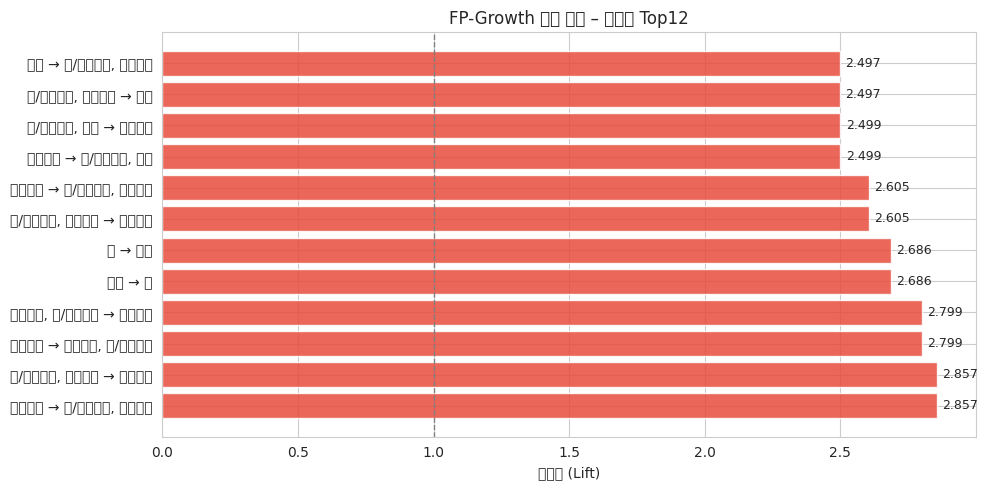


→ Lift > 1 : A 구매 시 B를 구매할 확률이 무작위 대비 높음
→ 채소류·두부·유정란 간 높은 연관성 → 묶음 상품 구성 및 장바구니 추천 전략에 활용


In [8]:
# ── FP-Growth: 동일 회원+주문시간 기준 Transaction ────────────
valid_p["transaction_key"] = (valid_p["회원번호"].astype(str)
                              + "_" + valid_p["주문시간"].astype(str))

basket = (valid_p.groupby(["transaction_key","물품대분류"])["물품대분류"]
          .count().unstack(fill_value=0))
basket = (basket > 0).astype(bool)

print(f"Transaction 수: {basket.shape[0]:,}  |  상품 대분류 수: {basket.shape[1]}")

freq_items = fpgrowth(basket, min_support=0.005, use_colnames=True)
rules = association_rules(freq_items, metric="lift", min_threshold=1.0,
                          num_itemsets=len(freq_items))
rules = rules.sort_values("lift", ascending=False)

# 표시용 정리
rules_disp = rules[["antecedents","consequents","support","confidence","lift"]].copy()
rules_disp["antecedents"]  = rules_disp["antecedents"].apply(lambda x: ", ".join(list(x)))
rules_disp["consequents"]  = rules_disp["consequents"].apply(lambda x: ", ".join(list(x)))
rules_disp = rules_disp.rename(columns={
    "antecedents":"조건(A)", "consequents":"결과(B)",
    "support":"지지도","confidence":"신뢰도","lift":"향상도"
})

print("\n[연관분석 Top10 상품쌍 – Lift 기준 내림차순]")
display(rules_disp.head(10).round(4).reset_index(drop=True))

# 시각화: 향상도 상위 규칙
fig, ax = plt.subplots(figsize=(10, 5))
top_rules = rules_disp.head(12)
colors_lift = ["#e74c3c" if l > 2 else "#f39c12" if l > 1.5 else "#3498db"
               for l in top_rules["향상도"]]
bars = ax.barh(
    [f"{a} → {b}" for a,b in zip(top_rules["조건(A)"], top_rules["결과(B)"])],
    top_rules["향상도"], color=colors_lift, alpha=0.85
)
ax.axvline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("향상도 (Lift)")
ax.set_title("FP-Growth 연관 규칙 – 향상도 Top12")
for bar, val in zip(bars, top_rules["향상도"]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\n→ Lift > 1 : A 구매 시 B를 구매할 확률이 무작위 대비 높음")
print("→ 채소류·두부·유정란 간 높은 연관성 → 묶음 상품 구성 및 장바구니 추천 전략에 활용")


## 6. 휴면 고객 정의 및 일반 고객과의 비교
### (발표자료 데이터 분석 3 – 슬라이드 16)

- 기준일: **2021년 10월 31일**
- 휴면 정의: 최근 **60일 미구매** 고객
- RFM 분석으로 일반 고객 vs 휴면 고객 비교


In [9]:
snapshot = pd.Timestamp("2021-10-31")

# ── RFM 계산 ──────────────────────────────────────────────────
rfm = valid.groupby("회원번호").agg(
    Recency   =("주문일시",  lambda x: (snapshot - x.max()).days),
    Frequency =("구매금액",  "count"),
    Monetary  =("구매금액",  "sum"),
).reset_index()

rfm["is_dormant"] = (rfm["Recency"] >= 60).astype(int)

rfm_m = rfm.merge(
    mem[["회원번호","구독여부","나이","회원상태"]], on="회원번호", how="left"
)
normal_rfm = rfm_m[rfm_m["회원상태"]=="정상회원"].copy()

dormant = normal_rfm[normal_rfm["is_dormant"]==1]
active  = normal_rfm[normal_rfm["is_dormant"]==0]

dormant_ratio = normal_rfm["is_dormant"].mean()
dormant_nonsub_ratio = (dormant["구독여부"]==False).mean()

print(f"전체 고객 중 휴면 고객 비율: {dormant_ratio:.1%}  ({dormant['is_dormant'].sum():,}명 / {len(normal_rfm):,}명)")
print(f"휴면 고객 중 비구독자 비율:  {dormant_nonsub_ratio:.1%}")
print()
print("[일반 고객 vs 휴면 고객 RFM 비교]")
rfm_compare = pd.DataFrame({
    "구분":       ["일반 고객","휴면 고객"],
    "Recency(일)":   [active["Recency"].mean(),   dormant["Recency"].mean()],
    "Frequency(회)": [active["Frequency"].mean(),  dormant["Frequency"].mean()],
    "Monetary(원)":  [active["Monetary"].mean(),   dormant["Monetary"].mean()],
}).set_index("구분")
display(rfm_compare.round(1))


전체 고객 중 휴면 고객 비율: 37.0%  (4,569명 / 12,340명)
휴면 고객 중 비구독자 비율:  68.2%

[일반 고객 vs 휴면 고객 RFM 비교]


,Recency(일),Frequency(회),Monetary(원)
구분,,,
일반 고객,16.4,75.8,889396.6
휴면 고객,159.3,9.0,112583.5


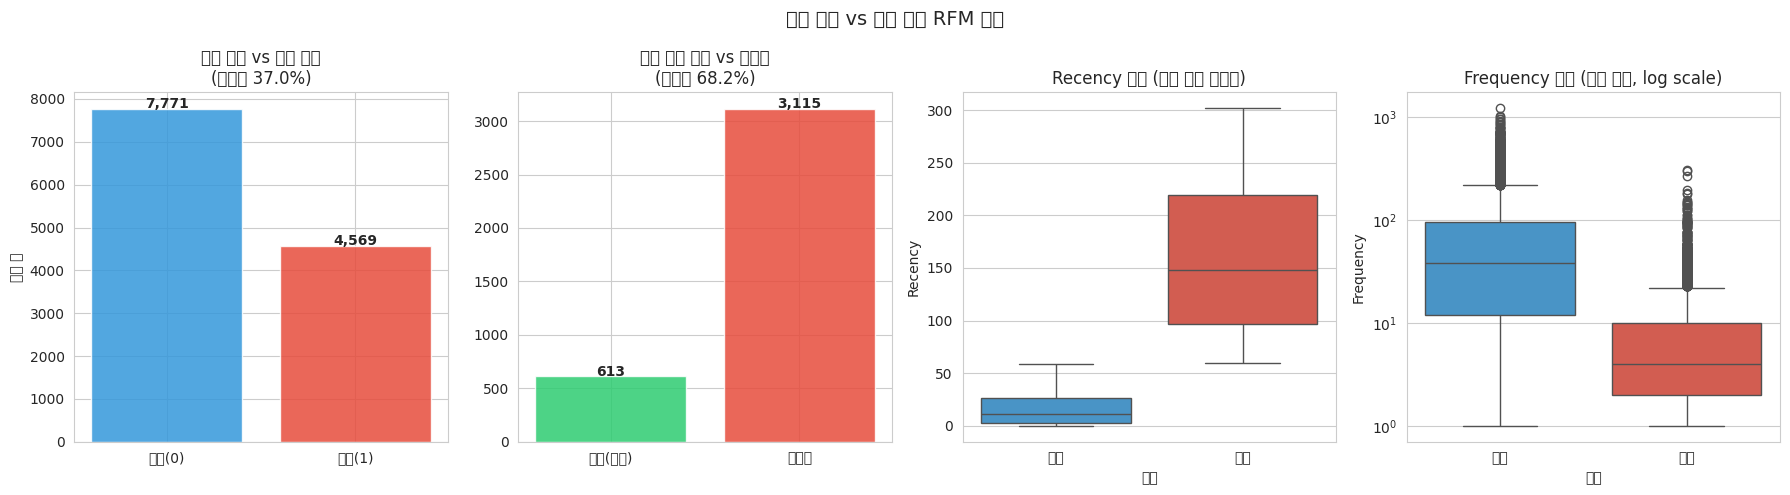

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# 일반 vs 휴면 비율
axes[0].bar(["일반(0)","휴면(1)"],
            [active["is_dormant"].shape[0], dormant["is_dormant"].shape[0]],
            color=["#3498db","#e74c3c"], alpha=0.85)
axes[0].set_title(f"일반 고객 vs 휴면 고객\n(휴면율 {dormant_ratio:.1%})")
axes[0].set_ylabel("회원 수")
for i,v in enumerate([len(active), len(dormant)]):
    axes[0].text(i, v+20, f"{v:,}", ha="center", fontweight="bold")

# 휴면 고객 구독 vs 비구독
d_sub = dormant["구독여부"].value_counts()
axes[1].bar(["유지(구독)","비구독"],
            [d_sub.get(True,0), d_sub.get(False,0)],
            color=["#2ecc71","#e74c3c"], alpha=0.85)
axes[1].set_title(f"휴면 고객 구독 vs 비구독\n(비구독 {dormant_nonsub_ratio:.1%})")
for i,v in enumerate([d_sub.get(True,0), d_sub.get(False,0)]):
    axes[1].text(i, v+5, f"{v:,}", ha="center", fontweight="bold")

# Recency BoxPlot
rfm_plot = pd.concat([
    active[["Recency"]].assign(구분="일반"),
    dormant[["Recency"]].assign(구분="휴면")
])
sns.boxplot(data=rfm_plot, x="구분", y="Recency",
            palette={"일반":"#3498db","휴면":"#e74c3c"},
            hue="구분", legend=False, ax=axes[2])
if _font: plt.rcParams["font.family"] = _font
axes[2].set_title("Recency 비교 (최근 구매 경과일)")

# Frequency BoxPlot (log)
rfm_freq = pd.concat([
    active[["Frequency"]].assign(구분="일반"),
    dormant[["Frequency"]].assign(구분="휴면")
])
sns.boxplot(data=rfm_freq, x="구분", y="Frequency",
            palette={"일반":"#3498db","휴면":"#e74c3c"},
            hue="구분", legend=False, ax=axes[3])
if _font: plt.rcParams["font.family"] = _font
axes[3].set_yscale("log")
axes[3].set_title("Frequency 비교 (구매 횟수, log scale)")

plt.suptitle("일반 고객 vs 휴면 고객 RFM 비교", fontsize=14)
plt.tight_layout()
plt.show()


## 7. 연령/위험군 기반 휴면 고객 분석
### (발표자료 데이터 분석 3 – 슬라이드 17)

휴면을 하나의 집단으로 보지 않고 **복귀 가능성 / 비용 대비 효과** 관점으로 세분화합니다.


[연령 구간별 휴면율]
  20-30대: 40.1%
  40-50대: 35.2%
  60대이상: 28.3%

[위험군 분류 기준]
  High (복귀 난이도↑): Frequency <= 3회
  Mid  (잠재 가치↑):   3회 < Frequency <= 7회
  Low  (관계 유지):    Frequency > 7회

[위험군 분포]


risk_group
High    1965
Low     1470
Mid     1134
Name: count, dtype: int64

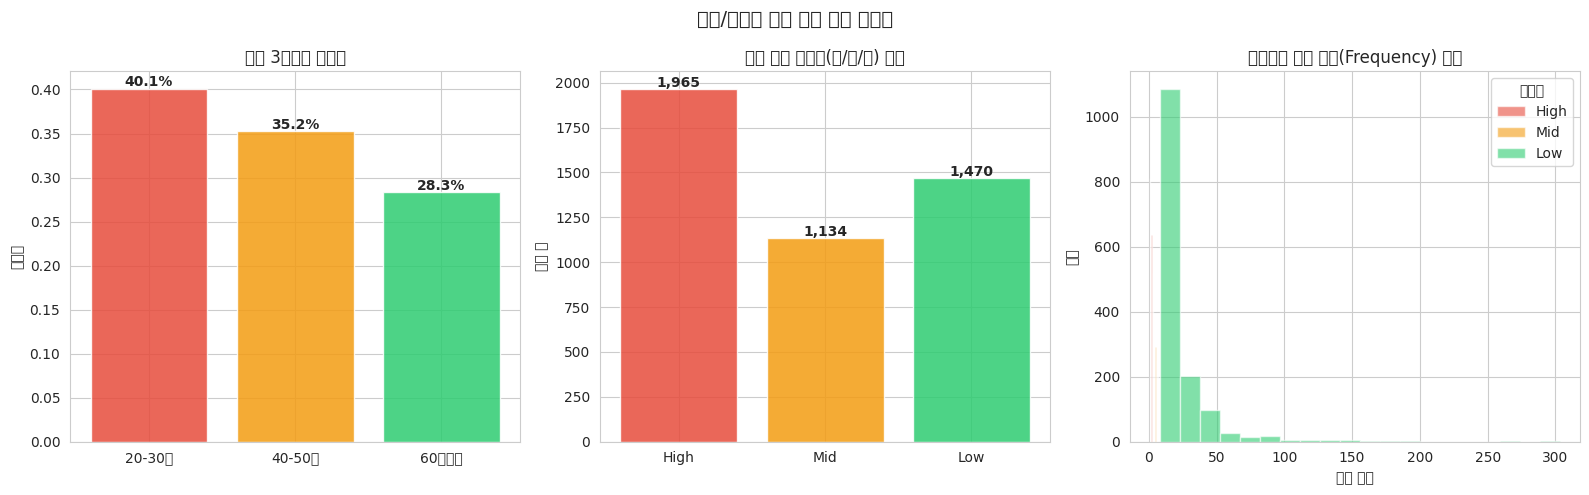


[위험군별 개입 전략]


,구분,정의,특징,목표,혜택,채널,발송시간
0,High 위험군,휴면 & 구매빈도↓,복귀 난이도↑,이탈 방지,무료배송·고액쿠폰(1만원+),푸시+카톡,오후 8시
1,Mid 위험군,휴면 & 구매빈도↑,잠재 가치↑,재구매 유도,소액쿠폰(5천원),푸시,오후 8시
2,Low 위험군,유지 고객,관계 유지 단계,비용 최적화,제공 없음,콘텐츠,월 1회


In [11]:
# ── 연령 구간별 휴면율 ────────────────────────────────────────
normal_rfm["age_group"] = pd.cut(
    normal_rfm["나이"], bins=[0,39,59,200],
    labels=["20-30대","40-50대","60대이상"]
)
age_dormant = normal_rfm.groupby("age_group")["is_dormant"].mean()

# ── 위험군 분류 ────────────────────────────────────────────────
# 휴면 고객 중 구매빈도(Frequency)로 상/중/하 분류
dormant2 = dormant.copy()
q33 = dormant2["Frequency"].quantile(0.33)
q66 = dormant2["Frequency"].quantile(0.66)
dormant2["risk_group"] = dormant2["Frequency"].apply(
    lambda f: "High" if f <= q33 else ("Mid" if f <= q66 else "Low")
)

print("[연령 구간별 휴면율]")
for grp, val in age_dormant.items():
    print(f"  {grp}: {val:.1%}")
print()

print("[위험군 분류 기준]")
print(f"  High (복귀 난이도↑): Frequency <= {q33:.0f}회")
print(f"  Mid  (잠재 가치↑):   {q33:.0f}회 < Frequency <= {q66:.0f}회")
print(f"  Low  (관계 유지):    Frequency > {q66:.0f}회")
print()
print("[위험군 분포]")
display(dormant2["risk_group"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 연령 구간별 휴면율
colors_age = ["#e74c3c","#f39c12","#2ecc71"]
axes[0].bar(age_dormant.index, age_dormant.values,
            color=colors_age, alpha=0.85)
axes[0].set_title("연령 3구간별 휴면율")
axes[0].set_ylabel("휴면율")
for i,(grp,v) in enumerate(age_dormant.items()):
    axes[0].text(i, v+0.003, f"{v:.1%}", ha="center", fontsize=10, fontweight="bold")

# 위험군 분포
rg = dormant2["risk_group"].value_counts().reindex(["High","Mid","Low"])
axes[1].bar(rg.index, rg.values,
            color=["#e74c3c","#f39c12","#2ecc71"], alpha=0.85)
axes[1].set_title("휴면 고객 위험군(상/중/하) 분포")
axes[1].set_ylabel("회원 수")
for i,v in enumerate(rg.values):
    axes[1].text(i, v+10, f"{v:,}", ha="center", fontweight="bold")

# 위험군별 RFM 비교 (Frequency)
for rg_name, color in [("High","#e74c3c"),("Mid","#f39c12"),("Low","#2ecc71")]:
    subset = dormant2[dormant2["risk_group"]==rg_name]["Frequency"]
    axes[2].hist(subset, bins=20, alpha=0.6, color=color, label=rg_name, edgecolor="white")
axes[2].set_title("위험군별 구매 빈도(Frequency) 분포")
axes[2].set_xlabel("구매 횟수")
axes[2].set_ylabel("빈도")
axes[2].legend(title="위험군")

plt.suptitle("연령/위험군 기반 휴면 고객 세분화", fontsize=14)
plt.tight_layout()
plt.show()

print()
print("[위험군별 개입 전략]")
tbl = pd.DataFrame({
    "구분":   ["High 위험군","Mid 위험군","Low 위험군"],
    "정의":   ["휴면 & 구매빈도↓","휴면 & 구매빈도↑","유지 고객"],
    "특징":   ["복귀 난이도↑","잠재 가치↑","관계 유지 단계"],
    "목표":   ["이탈 방지","재구매 유도","비용 최적화"],
    "혜택":   ["무료배송·고액쿠폰(1만원+)","소액쿠폰(5천원)","제공 없음"],
    "채널":   ["푸시+카톡","푸시","콘텐츠"],
    "발송시간":["오후 8시","오후 8시","월 1회"],
})
display(tbl)


## 8. 지역 기반 구독률 및 구매 패턴 분석


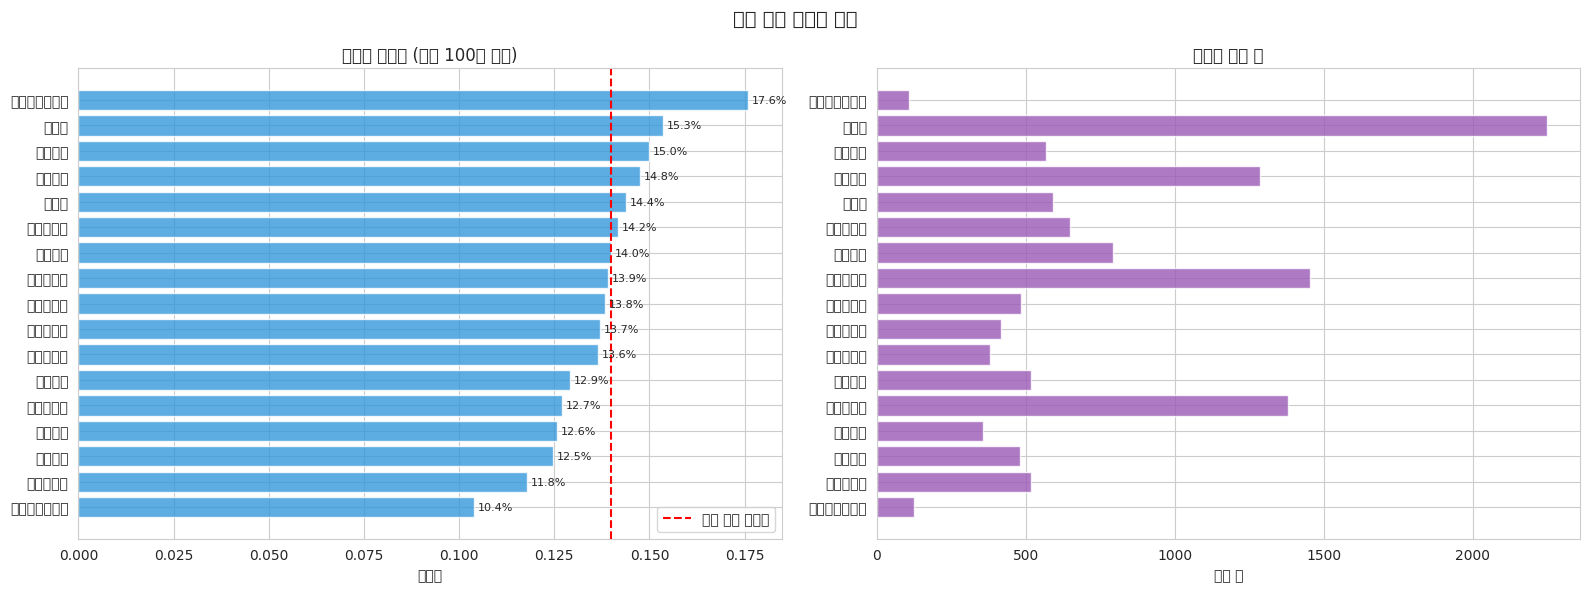

In [12]:
normal = mem[mem["회원상태"]=="정상회원"].copy()

region_stats = normal.groupby("주소지").apply(
    lambda x: pd.Series({
        "회원수":     len(x),
        "구독률":     (x["구독여부"]==True).mean(),
        "구독자수":   (x["구독여부"]==True).sum(),
    })
).reset_index()

region_stats = region_stats[region_stats["회원수"]>=100].sort_values("구독률", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 지역별 구독률
axes[0].barh(region_stats["주소지"][::-1], region_stats["구독률"][::-1],
             color="#3498db", alpha=0.8)
axes[0].axvline(normal["구독여부"].apply(lambda x: x==True).mean(),
                color="red", linestyle="--", linewidth=1.5, label="전체 평균 구독률")
axes[0].set_title("지역별 구독률 (회원 100명 이상)")
axes[0].set_xlabel("구독률")
axes[0].legend()
for i,(_, row) in enumerate(region_stats[::-1].iterrows()):
    axes[0].text(row["구독률"]+0.001, i, f"{row['구독률']:.1%}", va="center", fontsize=8)

# 지역별 회원수
axes[1].barh(region_stats["주소지"][::-1], region_stats["회원수"][::-1],
             color="#9b59b6", alpha=0.8)
axes[1].set_title("지역별 회원 수")
axes[1].set_xlabel("회원 수")

plt.suptitle("지역 기반 구독률 분석", fontsize=14)
plt.tight_layout()
plt.show()


## 9. 종합 인사이트 및 개선안

### 분석 결과 요약

| 분석 항목 | 핵심 발견 | 개선안 |
|-----------|-----------|--------|
| 구독 전환 요인 | 소비 규모 차이 없음 → **이용 패턴**이 전환 결정 | 구매 리듬 형성 고객 대상 구독 제안 노출 |
| 적립금/포인트 | 구독 전환에 통계적으로 **비유의** (p>0.05) | 금전 혜택보다 **이용 편의성** 중심 구독 설계 |
| 월별 인기상품 | 계절·월별 구매 패턴 존재 | **월별 인기 상품관** 운영, 리마인드 푸시 |
| 연관 분석 | 채소·두부·유정란 간 높은 연관성 | **장바구니 바텀시트** 도입, 묶음 상품 개발 |
| 휴면 비율 | 전체 고객의 **약 37%** 휴면 상태 | 30일/45일/60일 기준 단계적 개입 |
| 휴면 고객 특성 | 비구독자 비율 높음, 2·30대 휴면율 상대적 높음 | High/Mid 위험군 우선 개입으로 ROI 극대화 |

### 개선안 제시 요약

**구독자 전략**
1. 월별 인기 상품관 운영 – 주문빈도 높은 시기별 인기 상품 메인 배너 배치
2. 리마인드 푸시 알림 – 해당 시기 구매 이력 고객 대상 발송
3. 장바구니 바텀시트 도입 – 연관분석 결과 기반 함께 구매할 상품 제안
4. 묶음 상품 개발 (Bundling Marketing) – 두부+콩나물+유정란 패키지 등

**휴면 고객 집중 전략**
- 구매 공백 기반 단계적 개입: [30일] 리마인드 → [45일] 혜택 제안 → [60일] 복귀 캠페인
- High 위험군: 1만원 쿠폰 + 무료배송 (푸시+카톡, 오후 8시)
- Mid 위험군: 5천원 쿠폰 (푸시, 오후 8시)
- Low 위험군: 콘텐츠 중심 관계 유지 (월 1회)
